# Tagliare una linea con un punto
> Tagliare una linea con un punto non è un'attività banalissima da fare in Python, in questo nuovo post mostrerò tre possibili strade per farlo.

- toc: true
- badges: true
- comments: false
- author: Massimiliano Moraca
- categories: [point]
- image: images/logo.png

Questa volta l'argomento trattato non nasce da una attività simile fatta con QGIS come per gli altri [post](https://maxdragonheart.github.io/PyGIS-Blog/) precedenti ma dalla soluzione ad un problema in cui mi sono imbattuto e che mi ha portato via un po' di tempo con non pochi grattacapi!

La richiesta era semplice, all'apparenza, ma non avevo fatto i conti con i *[Floating Point](https://docs.python.org/3/tutorial/floatingpoint.html) problems*. In pratica, avendo una linea ed un punto lontano da essa dovevo trovare la distanza minima tra punto e lina e spezzare la linea sul punto di contatto tra la congiungente più corta tra punto e linea.

## Prima di iniziare


### Librerie
Per raggiungere l'obiettivo userò le librerie che seguono:

In [3]:
from matplotlib import pyplot as plt
from shapely import wkt
from shapely.ops import substring, nearest_points, snap, split
from shapely.geometry import Point, LineString

### Fonti dati

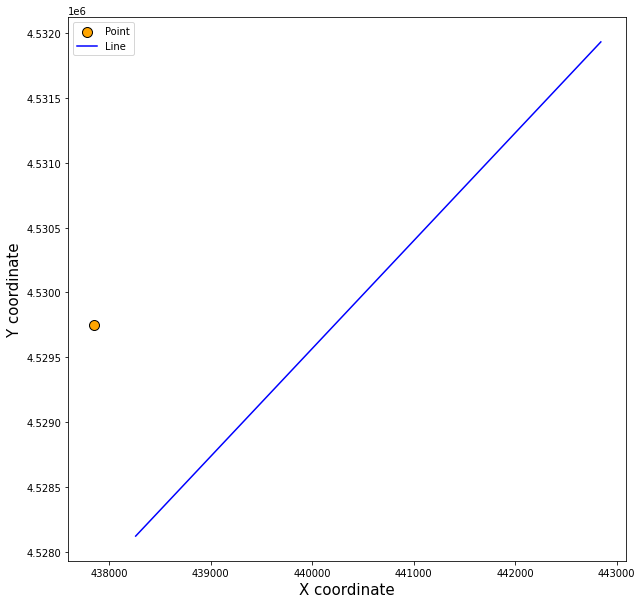

In [4]:
point = wkt.loads('POINT (437845.7257845374 4529752.584581757)')
line = wkt.loads('LINESTRING (438260.8093535866 4528121.6968436185, 442844.8639858717 4531930.850183684)')

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlabel('X coordinate', fontsize=15)
ax.set_ylabel('Y coordinate', fontsize=15)

ax.scatter(
    *point.xy,
    label='Point',
    s=100,
    facecolor='orange',
    edgecolor='black'
)
plt.plot(*line.xy, label='Line', color='blue')

plt.legend()

plt.show()

# Premessa

Ho capito delle difficoltà legate ai *floating point* dopo questa esperienza:

In [6]:
minimum_distance = nearest_points(point, line)[1]

Con `nearest_points()` ottengo il punto sulla linea più prossimo al mio punto di riferimento, a questo punto è naturale tagliare la linea con questo punto:

In [11]:
splitted_line = split(line, minimum_distance)

for line in list(splitted_line):
    print(line)

LINESTRING (438260.8093535866 4528121.6968436185, 442844.8639858717 4531930.850183684)


/tmp/ipykernel_15615/1721271714.py:3: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  for line in list(splitted_line):
/tmp/ipykernel_15615/1721271714.py:3: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for line in list(splitted_line):


La funzione `split()` restiuisce una *geometry collection* composta da due *LineString*. Almeno questo è quello che mi sarei aspettato leggendo anche la documentazione della libreria usata ma purtroppo anzicchè ottenere due linee ne ho ottenuta una, la linea in ingresso.
Quindi mi è sorto un dubbio: **ma il punto con cui ho provato a tagliare la linea è realmente sulla linea?**

In [13]:
snap_point = snap(minimum_distance, line, 1e-8)

assert minimum_distance.wkt == snap_point.wkt
assert line.distance(minimum_distance) < 1e-8

Gli `assert` non hanno dato esito negativo, quindi il punto è sulla linea. **E allora perchè non riesco a tagliarla??**

Facendo un po' di ricerche ho capito che il problema è legato ai *floating point* e così mi sono dato da fare per trovare una soluzione senza però trascurare altre possibili strade nel dubbio che magari potesse esserci un'altra strada o più di una. Infatti chiedendo un po' in giro ho trovato altre due soluzioni oltre la mia.

# 1. Soluzione mia

# 2. Soluzione basata su `projection()`

# 3. Soluzione basata su `snap()`

# Conclusione

Hai commenti, indicazioni o soluzioni alternative in Python? Scrivi nella sezione [Discussioni](https://github.com/MaxDragonheart/PyGIS-Blog/discussions).

**Se vuoi sponsorizza il progetto andando su [Sponsor this project](https://github.com/MaxDragonheart/PyGIS-Blog) nella home di questo repository.**

Alla prossima!